# Análisis incertidumbre

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / "pyproject.toml").exists(), f"Unexpected repo root: {REPO_ROOT}"

objects = pd.read_csv(REPO_ROOT / "results" / "tta_uq" / "object_level.csv", dtype={"image_id": str})
images = pd.read_csv(REPO_ROOT / "results" / "tta_uq" / "image_level.csv", dtype={"image_id": str})

print(f"Objetos: {len(objects)}  Imagenes: {len(images)}")

Objetos: 8051  Imagenes: 1496


In [2]:
print("Objetos por clase predicha:")
print(objects["pred_class_name"].value_counts().to_string())

print("\nObjetos por correctness:")
print(pd.DataFrame({
    "n": objects["correctness"].value_counts(),
    "%": objects["correctness"].value_counts(normalize=True).mul(100).round(1),
}))

total_gt = images["n_gt_objects"].sum()
total_fn = images["n_false_negatives"].sum()
print(f"\nObjetos GT totales: {total_gt}")
print(f"Falsos negativos (GT sin deteccion emparejada): {total_fn} ({100 * total_fn / total_gt:.1f}%)")

Objetos por clase predicha:
pred_class_name
car               5855
pedestrian         764
van                537
cyclist            318
truck              224
misc               203
tram               123
person_sitting      27

Objetos por correctness:
                   n     %
correctness               
correct         6935  86.1
false_positive  1055  13.1
wrong_class       61   0.8

Objetos GT totales: 8128
Falsos negativos (GT sin deteccion emparejada): 1183 (14.6%)


In [3]:
import itertools

AGG_METHODS = ["agg_max", "agg_mean", "agg_weighted_mean"]

top20_sets = {}
for method in AGG_METHODS:
    threshold = images[method].quantile(0.80)
    top20 = set(images.loc[images[method] >= threshold, "image_id"])
    top20_sets[method] = top20
    print(f"{method}: umbral (percentil 80) = {threshold:.4f}, {len(top20)} imagenes en el 20% mas incierto")

print("\nSolapamiento entre criterios de agregacion (Jaccard-similitud entre dos conjuntos = interseccion/union):")
for a, b in itertools.combinations(AGG_METHODS, 2):
    inter = len(top20_sets[a] & top20_sets[b])
    union = len(top20_sets[a] | top20_sets[b])
    print(f"  {a} vs {b}: interseccion={inter}  union={union}  Jaccard={100 * inter / union:.1f}%")

agg_max: umbral (percentil 80) = 0.6855, 300 imagenes en el 20% mas incierto
agg_mean: umbral (percentil 80) = 0.4888, 300 imagenes en el 20% mas incierto
agg_weighted_mean: umbral (percentil 80) = 0.4829, 300 imagenes en el 20% mas incierto

Solapamiento entre criterios de agregacion (Jaccard-similitud entre dos conjuntos = interseccion/union):
  agg_max vs agg_mean: interseccion=116  union=484  Jaccard=24.0%
  agg_max vs agg_weighted_mean: interseccion=113  union=487  Jaccard=23.2%
  agg_mean vs agg_weighted_mean: interseccion=286  union=314  Jaccard=91.1%


In [ ]:
MAP50_95 = {  
    "car": 0.717, "van": 0.663, "truck": 0.760, "pedestrian": 0.355,
    "person_sitting": 0.400, "cyclist": 0.439, "tram": 0.677, "misc": 0.559,
}

by_class = objects.groupby("pred_class_name").agg(
    n=("pixel_H_total_mean", "size"),
    H_total_mean=("pixel_H_total_mean", "mean"),
    class_unc_mean=("comp_class_uncertainty", "mean"),
)
by_class["map50_95"] = by_class.index.map(MAP50_95)
by_class = by_class.sort_values("map50_95")
print(by_class.round(4))

r_value = by_class["H_total_mean"].corr(by_class["map50_95"])
print(f"\nCorrelacion (Pearson) incertidumbre media vs mAP50-95: r={r_value:.3f}")
print("Aviso: n=8 clases -- correlacion descriptiva, no concluyente estadisticamente con tan pocos puntos.")

                    n  H_total_mean  class_unc_mean  map50_95
pred_class_name                                              
pedestrian        764        0.3877          0.0426     0.355
person_sitting     27        0.5116          0.1708     0.400
cyclist           318        0.4120          0.1013     0.439
misc              203        0.5229          0.2948     0.559
van               537        0.5157          0.3034     0.663
tram              123        0.4667          0.1144     0.677
car              5855        0.3212          0.0249     0.717
truck             224        0.4326          0.1014     0.760

Correlacion (Pearson) incertidumbre media vs mAP50-95: r=-0.092
Aviso: n=8 clases -- correlacion descriptiva, no concluyente estadisticamente con tan pocos puntos.


In [5]:
measures = ["pixel_H_total_mean", "pixel_Ue_mean", "comp_class_uncertainty", "comp_localization_uncertainty"]

summary = objects.groupby("correctness")[measures].agg(["count", "mean"])
print(summary.round(4))

print("\nMann-Whitney U (dos colas): correct vs (wrong_class + false_positive), por medida")
is_correct = objects["correctness"] == "correct"
for m in measures:
    u_stat, p_value = stats.mannwhitneyu(objects.loc[is_correct, m], objects.loc[~is_correct, m],
                                          alternative="two-sided")
    flag = "SIGNIFICATIVO (p<0.05)" if p_value < 0.05 else "no significativo"
    print(f"  {m:30s} p={p_value:.2e}  {flag}")

               pixel_H_total_mean         pixel_Ue_mean          \
                            count    mean         count    mean   
correctness                                                       
correct                      6935  0.3612          6935  0.3512   
false_positive               1055  0.3041          1055  0.2969   
wrong_class                    61  0.5510            61  0.4968   

               comp_class_uncertainty         comp_localization_uncertainty  \
                                count    mean                         count   
correctness                                                                   
correct                          6935  0.0547                          6935   
false_positive                   1055  0.0666                          1055   
wrong_class                        61  0.4082                            61   

                        
                  mean  
correctness             
correct         1.3953  
false_positive  1.0017

In [11]:
print("Mann-Whitney U (dos colas), correct vs cada tipo de error POR SEPARADO:")
for other in ["wrong_class", "false_positive"]:
    print(f"\n  correct vs {other} (n={ (objects['correctness'] == other).sum() }):")
    for m in measures:
        vals_correct = objects.loc[is_correct, m]
        vals_other = objects.loc[objects["correctness"] == other, m]
        u_stat, p_value = stats.mannwhitneyu(vals_correct, vals_other, alternative="two-sided")
        direction = "mayor" if vals_other.mean() > vals_correct.mean() else "menor"
        flag = "SIGNIFICATIVO" if p_value < 0.05 else "no significativo"
        print(f"    {m:30s} {other} {direction} que correct  p={p_value:.2e}  ({flag})")

Mann-Whitney U (dos colas), correct vs cada tipo de error POR SEPARADO:

  correct vs wrong_class (n=61):
    pixel_H_total_mean             wrong_class mayor que correct  p=5.18e-09  (SIGNIFICATIVO)
    pixel_Ue_mean                  wrong_class mayor que correct  p=4.04e-06  (SIGNIFICATIVO)
    comp_class_uncertainty         wrong_class mayor que correct  p=1.33e-27  (SIGNIFICATIVO)
    comp_localization_uncertainty  wrong_class mayor que correct  p=8.12e-06  (SIGNIFICATIVO)

  correct vs false_positive (n=1055):
    pixel_H_total_mean             false_positive menor que correct  p=1.43e-21  (SIGNIFICATIVO)
    pixel_Ue_mean                  false_positive menor que correct  p=8.33e-22  (SIGNIFICATIVO)
    comp_class_uncertainty         false_positive mayor que correct  p=4.50e-81  (SIGNIFICATIVO)
    comp_localization_uncertainty  false_positive menor que correct  p=2.13e-16  (SIGNIFICATIVO)


In [7]:
import random
import sys

import cv2
import matplotlib.pyplot as plt
import yaml
from ultralytics import YOLO

sys.path.insert(0, str(REPO_ROOT / "src"))
from xai_benchmark.data.kitti_dataset import load_kitti_yolo_bboxes
from xai_benchmark.uncertainty.tta import (
    run_image_tta, match_tta_to_anchor, match_detections_to_gt,
    union_canvas, pixel_level_uncertainty,
)

with open(REPO_ROOT / "configs" / "tta_uq.yaml", "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

CHECKPOINT = REPO_ROOT / cfg["checkpoint"]
val_images_dir = REPO_ROOT / cfg["data"]["val_images_dir"]
val_labels_dir = REPO_ROOT / cfg["data"]["val_labels_dir"]

model_dense = YOLO(str(CHECKPOINT))   # SOLO run_image_tta, nunca .predict()/.val()
model_prep = YOLO(str(CHECKPOINT))    # SOLO para preprocesar
dummy = cv2.imread(str(sorted(val_images_dir.glob("*.png"))[0]))
model_prep.predict([dummy], verbose=False, device=0)

rng = random.Random(cfg["tta"]["seed"])
print("Modelo cargado para verificacion visual.")

Modelo cargado para verificacion visual.


Mas incierta (agg_mean): 004018 (score=0.7701)
Mas falsos negativos: 005663 (FN=10)
004018: 3 objetos, 3 GT, 0 falsos negativos


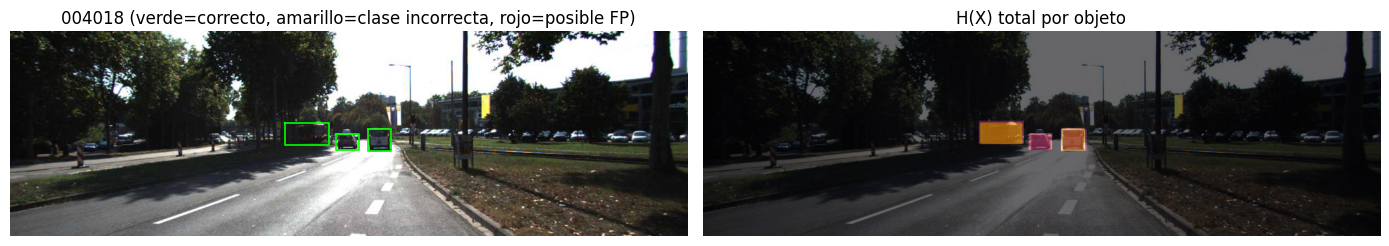

005663: 16 objetos, 21 GT, 10 falsos negativos


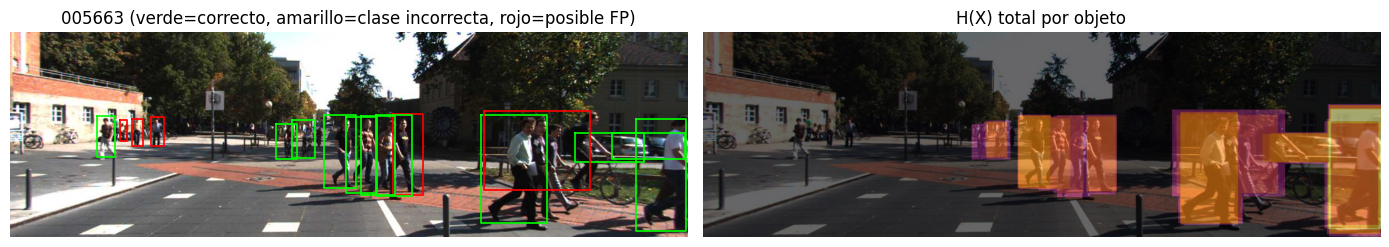

In [10]:
# Imagen mas incierta segun agg_mean, e imagen con mas falsos negativos
most_uncertain = images.loc[images["agg_mean"].idxmax()]
most_fn = images.loc[images["n_false_negatives"].idxmax()]
chosen_ids = list(dict.fromkeys([most_uncertain["image_id"], most_fn["image_id"]]))
print(f"Mas incierta (agg_mean): {most_uncertain['image_id']} (score={most_uncertain['agg_mean']:.4f})")
print(f"Mas falsos negativos: {most_fn['image_id']} (FN={most_fn['n_false_negatives']})")


def visualize_image(image_id):
    img_bgr = cv2.imread(str(val_images_dir / f"{image_id}.png"))
    img_h, img_w = img_bgr.shape[:2]
    txt_path = val_labels_dir / f"{image_id}.txt"
    gt_labels = (load_kitti_yolo_bboxes(str(txt_path), img_h, img_w, return_class=True, box_format="xyxy")
                 if txt_path.exists() else [])

    anchor, tta_passes, _ = run_image_tta(
        model_dense, model_prep, img_bgr, rng,
        n_tta=cfg["tta"]["n_tta"], conf_thres=cfg["detection"]["conf_thres"],
        iou_thres_nms=cfg["detection"]["iou_thres_nms"],
    )
    if len(anchor.boxes) == 0:
        print(f"{image_id}: sin detecciones del ancla, nada que pintar.")
        return

    matches = match_tta_to_anchor(anchor, tta_passes, cfg["matching"]["iou_thres_tta_anchor"])
    gt_matches, matched_gt_idx = match_detections_to_gt(anchor, gt_labels, cfg["matching"]["iou_thres_gt"])
    num_classes = anchor.class_probs.shape[-1]
    print(f"{image_id}: {len(anchor.boxes)} objetos, {len(gt_labels)} GT, "
          f"{len(gt_labels) - len(matched_gt_idx)} falsos negativos")

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    heat = np.zeros((img_h, img_w), dtype=np.float32)
    for j in range(len(anchor.boxes)):
        canvas = union_canvas(anchor, tta_passes, matches, j)
        pix = pixel_level_uncertainty(tta_passes, matches, j, canvas, num_classes)
        if pix is None:
            continue
        x1, y1, x2, y2 = canvas
        heat[y1:y2, x1:x2] = np.maximum(heat[y1:y2, x1:x2], pix["H_total"].numpy())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].imshow(img_rgb)
    colors = {"correct": "lime", "wrong_class": "yellow", "false_positive": "red"}
    for j in range(len(anchor.boxes)):
        x1, y1, x2, y2 = anchor.boxes[j].tolist()
        axes[0].plot([x1, x2, x2, x1, x1], [y1, y1, y2, y2, y1], colors[gt_matches[j][2]], linewidth=1.2)
    axes[0].set_title(f"{image_id} (verde=correcto, amarillo=clase incorrecta, rojo=posible FP)")
    axes[0].axis("off")
    axes[1].imshow(img_rgb)
    axes[1].imshow(heat, cmap="inferno", alpha=0.6)
    axes[1].set_title("H(X) total por objeto")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()


for image_id in chosen_ids:
    visualize_image(image_id)

## Interpretación — estudio de incertidumbre sobre el val set completo (1496 imágenes, 8051 objetos)

**Replicación de la Sección 5.3.4 de la tesis (Celda 3), confirmada**: `mean` y `weighted_mean`
solapan al 91.1% en qué imágenes marcan como el 20% más incierto — coincide con el ">80%" que
reporta la propia tesis. `max` diverge fuertemente de ambos (Jaccard ~23-24%): un solo objeto
pequeño con entropía alta dispara el máximo de toda la imagen aunque el resto esté clarísimo
(el caso de `004005.png` del smoke test es exactamente este patrón). Confirma, sobre KITTI+YOLO26,
la misma conclusión práctica de la tesis: la media agregada es más robusta que el máximo.

**Desglose por clase (Celda 4): correlación global débil (r=-0.092, n=8, no concluyente) pero
patrón desagregado interpretable**. `car` (n=5855, mejor clase, mAP50-95=0.717) tiene la menor
incertidumbre, como cabría esperar. Pero `truck` (mAP50-95=0.760, la mejor de todas) y `tram`
(0.677) muestran incertidumbre moderada-alta, similar o mayor que `pedestrian` (mAP50-95=0.355,
la peor) — la incertidumbre por TTA mide sensibilidad de la clasificación a los aumentos, no
accuracy de detección, y ambas cosas no tienen por qué coincidir. Lo más interesante: **`van` y
`misc` son, con diferencia, las dos clases con mayor `class_uncertainty`** (0.3034 y 0.2948,
frente a 0.0249 de `car`) — coherente en ambos casos: `van` es la clase más confundible
visualmente con `car` (ya visto en el smoke test con un objeto "van" concreto con `U_a`
disparado), y `misc` es por definición la categoría heterogénea de KITTI. Aviso: `person_sitting`
(n=27) y `tram` (n=123) tienen muestras pequeñas, sus medias son menos fiables.

**`correctness` vs incertidumbre (Celdas 5-6), con los tres grupos separados**:

- **`wrong_class`** (n=61, caja bien localizada, clase equivocada): incertidumbre
  significativamente **mayor** que `correct` en las 4 medidas, con `comp_class_uncertainty`
  disparado (0.4082 vs 0.0547, p=1.33e-27). Validación clara y sin matices: cuando el
  modelo confunde la clase, la incertidumbre de clase lo capta con fuerza.
- **`false_positive`** (n=1055, detección sin correspondencia real en el GT): el resultado
  depende de qué medida se mire. `pixel_H_total`, `pixel_Ue` y `comp_localization_uncertainty` 
  son **significativamente más bajas** que en `correct` (p=1.43e-21, 8.33e-22, 2.13e-16), 
  el modelo tiende a "alucinar" objetos con cajas estables y consistentes entre pasadas de TTA, 
  no con incertidumbre visible a nivel de píxel o localización. Pero `comp_class_uncertainty` sí 
  es **significativamente más alta** que en `correct` (p=4.50e-81), aunque con un efecto mucho más 
  modesto que en `wrong_class`. Es decir:
  la incertidumbre de píxel/localización no sirve para detectar falsos positivos (al contrario,
  engaña, sugiriendo confianza), pero la incertidumbre de clase a nivel de componente sí
  conserva algo de señal, aunque débil. Ninguna medida por sí sola cubre bien los tres tipos de
  fallo — es un argumento a favor de calcular ambos niveles (píxel y componente) en vez de
  quedarse solo con uno.


**Casos concretos (Celda 7)**: `004018` (mayor incertidumbre agregada de las 1496, 0.7701)
tiene sus 3 objetos correctamente clasificados y localizados (0 falsos negativos) — vehículos
pequeños y lejanos al fondo de la carretera. Ilustra que "incertidumbre alta" no equivale a
"detección incorrecta": aquí el modelo acierta, pero el objeto es intrínsecamente difícil, y
eso es justo lo que debería capturar una medida de incertidumbre útil. `005663` (más falsos
negativos, 10 de 21 GT) es una escena de peatones concurrida con varias cajas rojas (falsos
positivos) entre grupos solapados — aquí sí coincide incertidumbre alta con errores reales
(peatón, clase débil), concentrada visiblemente sobre los grupos más densos.

**Conclusión general**: el método captura bien la dificultad intrínseca de los objetos
(pequeños/lejanos, clases visualmente confundibles como van/car, clases heterogéneas como
misc, escenas de peatones solapados) y la confusión de clase en detecciones ya localizadas de
forma inequívoca. Frente a los falsos positivos el resultado es más matizado: la incertidumbre
de píxel/localización los pasa por alto (incluso sugiere lo contrario), pero la de clase a
nivel de componente conserva una señal débil mas real. Información directamente relacionable
con las explicaciones XAI (SSGrad-CAM++/D-CRISP) sobre estos falsos positivos  "confiados en su 
localización pero dudosos en su clase" muestren un patrón de atención distinto al de las detecciones 
correctas — un puente natural entre UQ y XAI a explorar.